In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load DataSet

In [56]:
df = pd.read_csv("ai_model_experiments.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experiment_id      5000 non-null   int64  
 1   Model              5000 non-null   object 
 2   dataset            5000 non-null   object 
 3   gpu_type           5000 non-null   object 
 4   batch_size         5000 non-null   int64  
 5   accuracy           5000 non-null   float64
 6   latency_ms         5000 non-null   float64
 7   tokens_per_second  5000 non-null   float64
 8   memory_usage_gb    5000 non-null   float64
 9   compute_cost_usd   5000 non-null   float64
 10  run_timestamp      5000 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 429.8+ KB


,experiment_id,batch_size,accuracy,latency_ms,tokens_per_second,memory_usage_gb,compute_cost_usd
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,5.278400,0.808710,200.006746,76.768092,20.572182,1.722708
std,1443.520003,4.745967,0.039013,38.470512,18.323632,4.461808,0.294789
min,1.000000,1.000000,0.680000,84.840000,17.860000,5.590000,0.777000
25%,1250.750000,2.000000,0.782000,172.760000,63.745000,17.497500,1.510000
50%,2500.500000,4.000000,0.809000,199.710000,76.855000,20.480000,1.721000
75%,3750.250000,8.000000,0.837000,227.422500,90.440000,23.630000,1.932000
max,5000.000000,16.000000,0.930000,327.160000,136.660000,37.720000,2.600000


# Data Cleaning and Preprocessing

In [57]:
print(df.isnull().sum())
print(df.duplicated().sum())

experiment_id        0
Model                0
dataset              0
gpu_type             0
batch_size           0
accuracy             0
latency_ms           0
tokens_per_second    0
memory_usage_gb      0
compute_cost_usd     0
run_timestamp        0
dtype: int64
0



# Exploratory Data Analysis (EDA)

In [58]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['experiment_id', 'batch_size', 'accuracy', 'latency_ms',
       'tokens_per_second', 'memory_usage_gb', 'compute_cost_usd'],
      dtype='object')
Categorical Features: Index(['Model', 'dataset', 'gpu_type', 'run_timestamp'], dtype='object')


Text(0.5, 1.0, 'Accuracy Distribution')

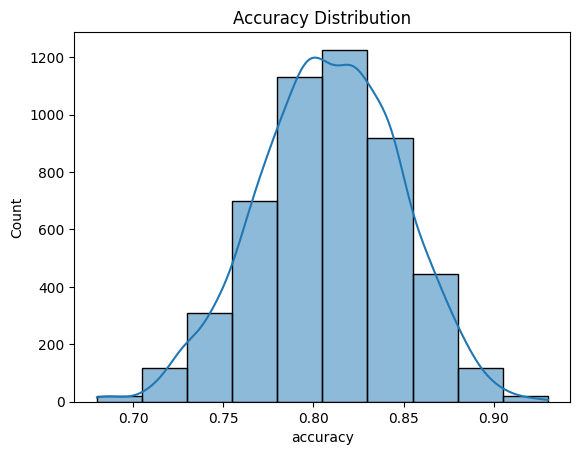

In [59]:
plt.figure()
sns.histplot(df["accuracy"],bins=10, kde=True)
plt.title("Accuracy Distribution")

Text(0.5, 1.0, 'Compute Cost Distribution')

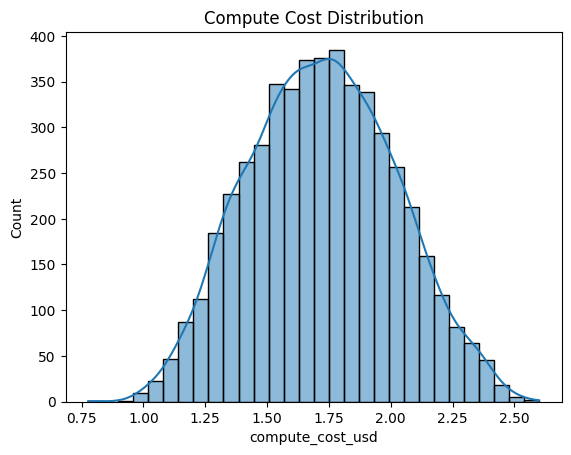

In [60]:
plt.figure()
sns.histplot(df["compute_cost_usd"], bins=30,kde=True)
plt.title("Compute Cost Distribution")

Text(0.5, 1.0, 'Outlier Analysis: Memory Usage')

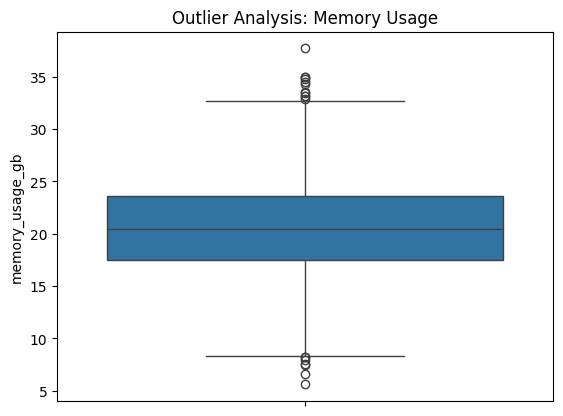

In [61]:
plt.figure()
sns.boxplot(y=df["memory_usage_gb"])
plt.title("Outlier Analysis: Memory Usage")

Text(0.5, 1.0, 'Outlier Analysis: Tokens per Second')

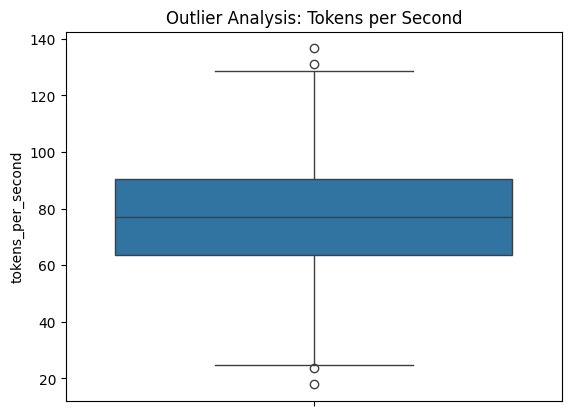

In [62]:
plt.figure()
sns.boxplot(y=df["tokens_per_second"])
plt.title("Outlier Analysis: Tokens per Second")

# Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

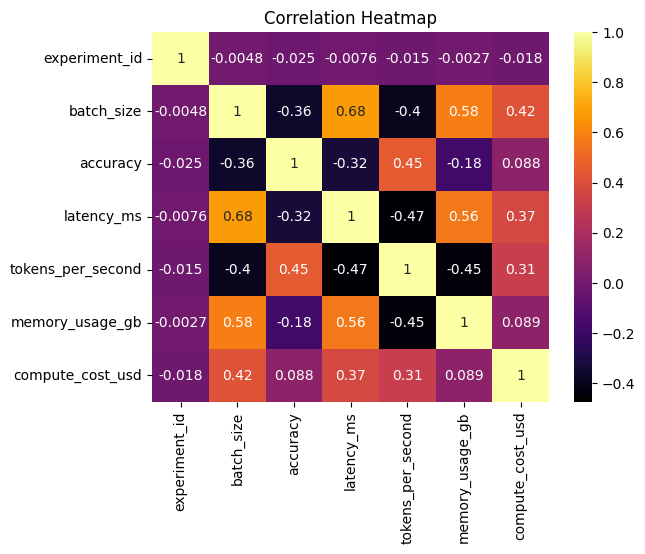

In [63]:
df_numerical = df[numerical_features]
plt.figure()
sns.heatmap(df_numerical.corr(), annot=True, cmap="inferno")
plt.title("Correlation Heatmap")

# IQR Testing

In [64]:
iqr_features = [col for col in numerical_features if col != "experiment_id"]
iqr_summary = []

for col in iqr_features:
    data = df[col].dropna()
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    iqr_summary.append({
        "feature": col,
        "Q1": round(q1, 3),
        "Q3": round(q3, 3),
        "IQR": round(iqr, 3),
        "lower_bound": round(lower_bound, 3),
        "upper_bound": round(upper_bound, 3),
        "outlier_count": int(outliers.shape[0]),
        "outlier_percent": round((outliers.shape[0] / data.shape[0]) * 100, 2),
    })

iqr_results = pd.DataFrame(iqr_summary).sort_values("outlier_percent", ascending=False)
print("IQR Outlier Summary by Numeric Feature")
iqr_results

IQR Outlier Summary by Numeric Feature


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
1,accuracy,0.782,0.837,0.055,0.700,0.919,22,0.44
4,memory_usage_gb,17.498,23.630,6.132,8.299,32.829,18,0.36
2,latency_ms,172.760,227.422,54.662,90.766,309.416,8,0.16
3,tokens_per_second,63.745,90.440,26.695,23.702,130.483,4,0.08
5,compute_cost_usd,1.510,1.932,0.422,0.877,2.565,2,0.04
0,batch_size,2.000,8.000,6.000,-7.000,17.000,0,0.00


# Training Model

In [ ]:
feature_cols = ["latency_ms", "tokens_per_second", "memory_usage_gb", "batch_size", "Model", "dataset", "gpu_type"]
x = pd.get_dummies(df[feature_cols], columns=["Model", "dataset", "gpu_type"], drop_first=True)
y = df["compute_cost_usd"]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = model.score(X_test, Y_test)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

results = pd.DataFrame({"Actual": Y_test.values, "Predicted": y_pred})
results.head()

MSE: 0.0052
R2 Score: 0.9427
Intercept: 0.8871


,Actual,Predicted
0,1.812,1.708471
1,1.436,1.459424
2,1.918,1.840313
3,1.924,2.010346
4,1.357,1.451120


# Plotting Results

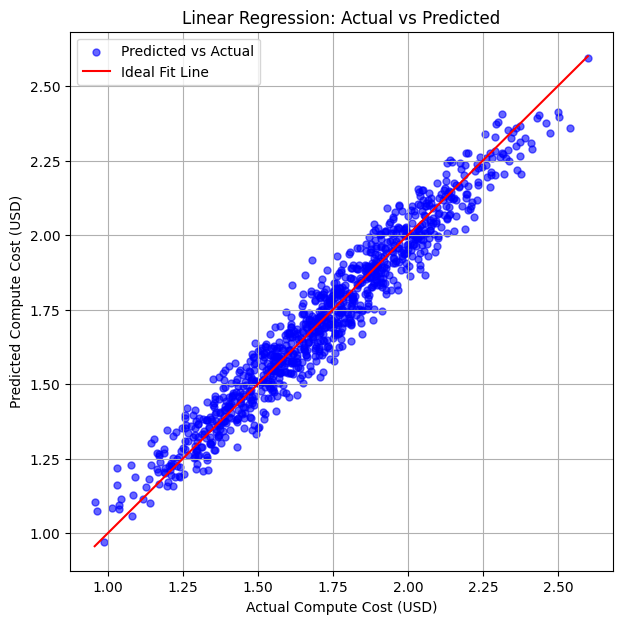

In [66]:
plt.figure(figsize=(7, 7))
plt.scatter(Y_test, y_pred, color='blue', alpha=0.6, s=25, label='Predicted vs Actual')

line_min = min(Y_test.min(), y_pred.min())
line_max = max(Y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], color='red', label='Ideal Fit Line')

plt.xlabel("Actual Compute Cost (USD)")
plt.ylabel("Predicted Compute Cost (USD)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)

# Visualizations

Text(0, 0.5, 'Average Compute Cost (USD)')

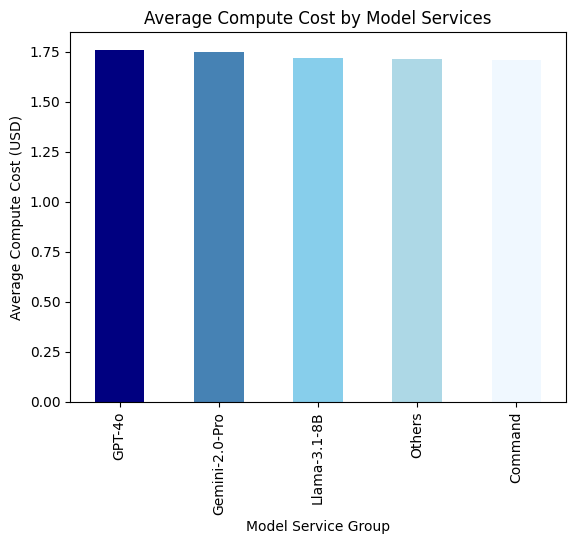

In [78]:
# Bar Chart: Average compute cost by model services vs others
model_services = ["GPT-4o", "Gemini-2.0-Pro", "Llama-3.1-8B", "Command"]
df_model_services = df[["Model", "compute_cost_usd"]].copy()
df_model_services["model_service_group"] = np.where(df_model_services["Model"].isin(model_services), df_model_services["Model"], "Others")

avg_cost_by_model_service = df_model_services.groupby("model_service_group")["compute_cost_usd"].mean().sort_values(ascending=False)
avg_cost_by_model_service.plot(kind='bar', color=["navy", "steelblue", "skyblue", "lightblue", "aliceblue"] )
plt.title("Average Compute Cost by Model Services")
plt.xlabel("Model Service Group")
plt.ylabel("Average Compute Cost (USD)")

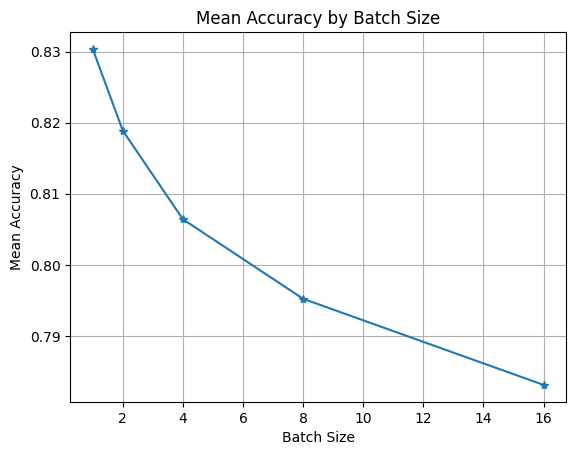

In [68]:
# Line Plot: Mean accuracy by batch size
mean_accuracy_by_batch = df.groupby("batch_size")["accuracy"].mean().sort_index()
plt.figure()
plt.plot(mean_accuracy_by_batch.index, mean_accuracy_by_batch.values, marker="*")
plt.title("Mean Accuracy by Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Mean Accuracy")
plt.grid(True)

Text(0.5, 1.0, 'GPU Type Distribution')

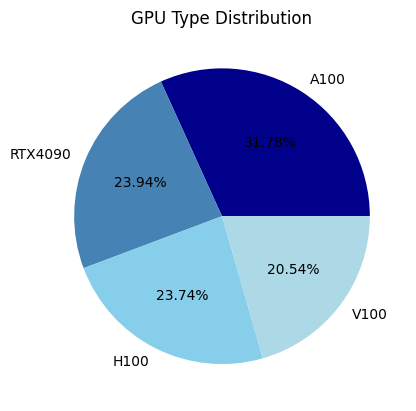

In [74]:
# Pie Chart: GPU type share in total experiments
gpu_count = df["gpu_type"].value_counts()
plt.figure()
plt.pie(gpu_count, labels=gpu_count.index, autopct="%1.2f%%", colors=["darkblue", "steelblue", "skyblue", "lightblue"] )
plt.title("GPU Type Distribution")

Text(0.5, 1.0, 'Latency vs Tokens per Second')

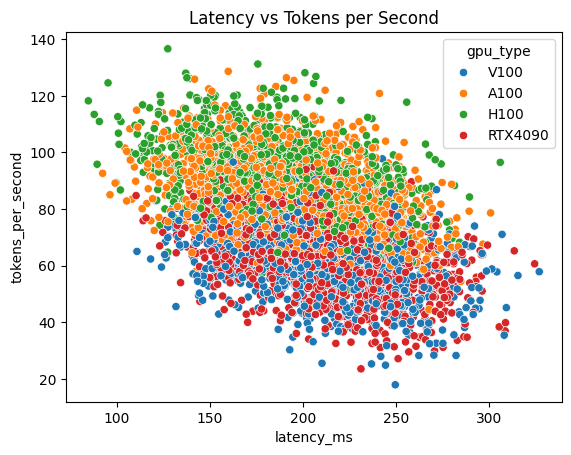

In [70]:
# Scatter Plot: Latency vs tokens per second by GPU type
plt.figure()
sns.scatterplot(x="latency_ms", y="tokens_per_second", hue="gpu_type", data=df)
plt.title("Latency vs Tokens per Second")

Text(0.5, 1.0, 'Feature Correlation Heat Map')

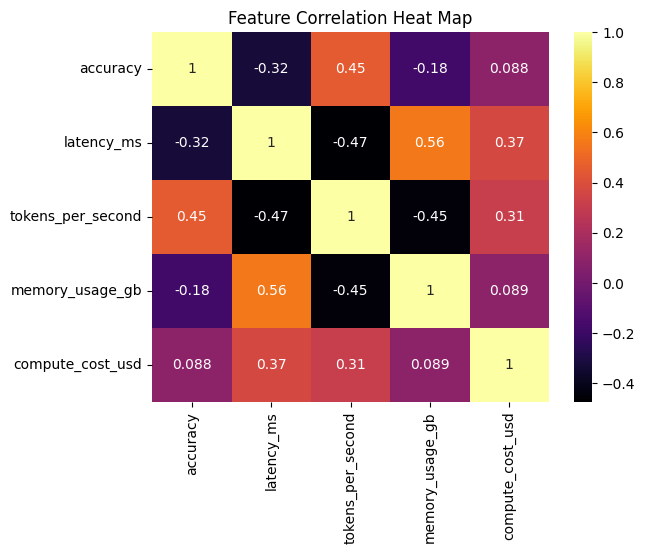

In [71]:
# Heat Map: Correlation among numeric performance features
plt.figure()
sns.heatmap(df[["accuracy", "latency_ms", "tokens_per_second", "memory_usage_gb", "compute_cost_usd"]].corr(), annot=True, cmap="inferno")
plt.title("Feature Correlation Heat Map")